## logistic function is a linear regression is a type of sigmoid, a call of function with the same specific properties.sigmoid  is a mathematical function that take any real numbers and maps to probability betweeen 1 and 0

In [1]:
import numpy as np
import matplotlib.pyplot as plt


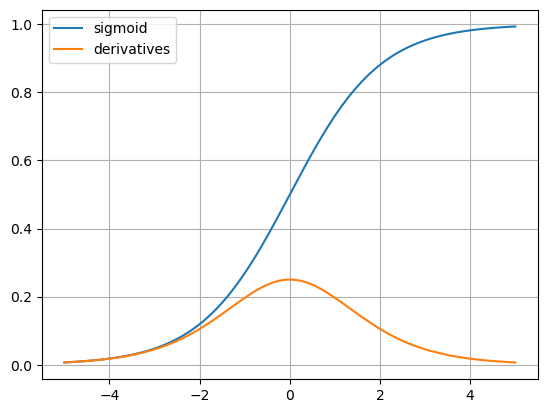

In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
def derivatives(x,steps):
    return(sigmoid(x+steps)-sigmoid(x))/steps
x=np.linspace(-5,5,1000)
y1=sigmoid(x)
y2=derivatives(x,0.000000000001)
plt.plot(x,y1,label='sigmoid')
plt.plot(x,y2,label='derivatives')
plt.legend()
plt.grid()
plt.show()

## Logistics function does not predict a class directly (0 or 1) it Preedict the Probability that a sample belong to class 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score

In [4]:
import seaborn as sns

In [5]:
df=sns.load_dataset('titanic')

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
print(df.shape)
print(df.info())

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [8]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [10]:
x=df[['pclass','sex','age','fare']]
x.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


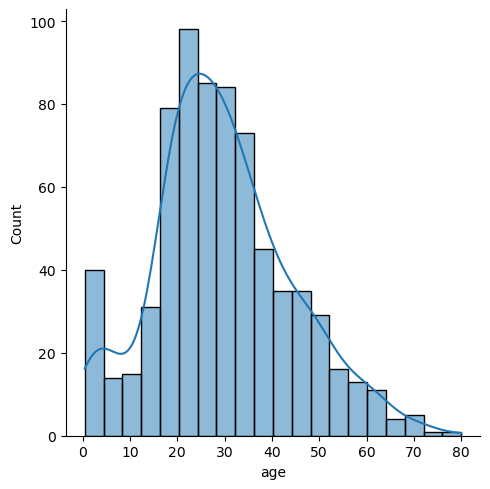

In [11]:
sns.displot(data=df,x="age",kde=True)

In [12]:
print(df['age'].mean())
print(df['age'].median())

29.69911764705882
28.0


In [13]:
y=df['survived']

In [14]:
print(x.isnull().sum())

pclass      0
sex         0
age       177
fare        0
dtype: int64


In [15]:
x=df[['pclass','sex','age','fare']].copy()

In [16]:
x['age']=x['age'].fillna(x['age'].median())

In [17]:
print(x.isnull().sum())

pclass    0
sex       0
age       0
fare      0
dtype: int64


<Figure size 1200x600 with 0 Axes>

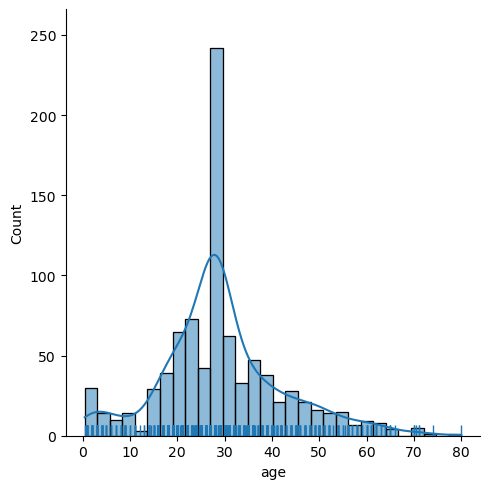

In [18]:
plt.figure(figsize=(12,6))
sns.displot(data=x,x='age',kde=True,rug=True)

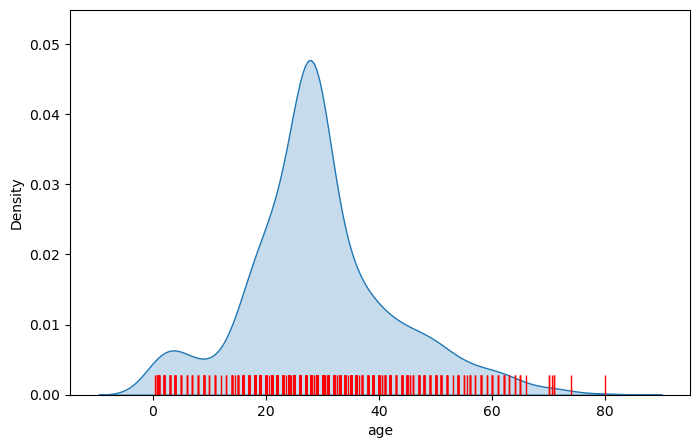

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=x,x='age',fill=True)
sns.rugplot(data=x,x='age',height=0.05,color='red')
plt.show()

<Axes: xlabel='fare', ylabel='Density'>

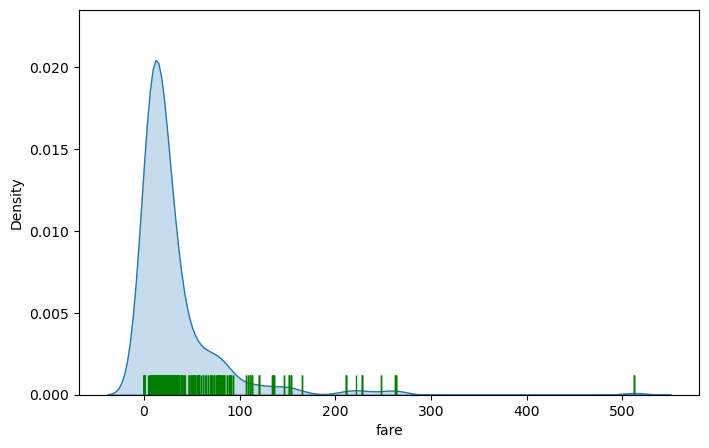

In [20]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=x,x='fare',fill=True)
sns.rugplot(data=x,x='fare',height=0.05,color='green')

<Axes: xlabel='pclass', ylabel='count'>

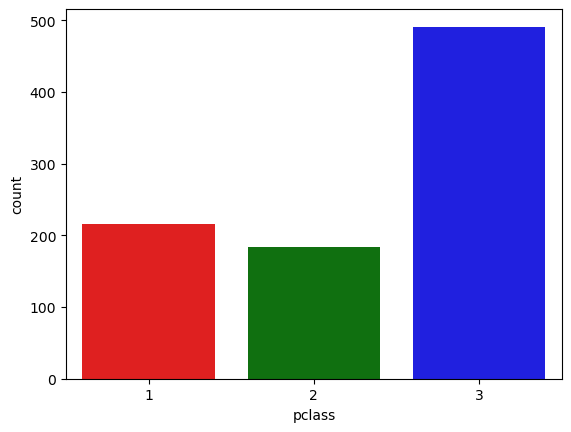

In [21]:
import warnings
warnings.filterwarnings('ignore')
sns.countplot(data=x,x='pclass',palette=['red','green','blue'])

In [22]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

<Axes: ylabel='count'>

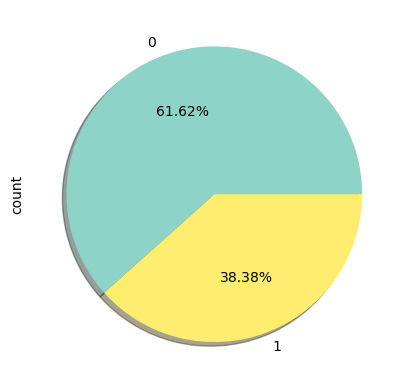

In [23]:
df['survived'].value_counts().plot(kind='pie',autopct='%1.2f%%',shadow=True,cmap='Set3')

In [24]:
print(df[(df['pclass']==3)&(df['survived']==0)].shape[0])
print(df[(df['pclass']==2)&(df['survived']==0)].shape[0])
print(df[(df['pclass']==1)&(df['survived']==0)].shape[0])

372
97
80


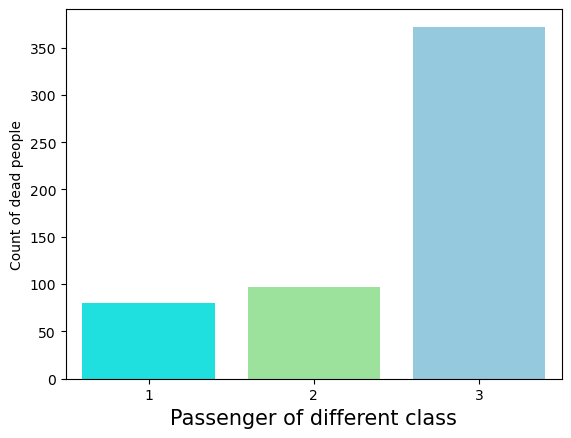

In [25]:
dead=df[df['survived']==0]
sns.countplot(data=dead,x='pclass',order=[1,2,3],palette=['aqua','lightgreen','skyblue'])
plt.xlabel("Passenger of different class",fontsize=15)
plt.ylabel("Count of dead people")
plt.show()

<Axes: xlabel='pclass', ylabel='count'>

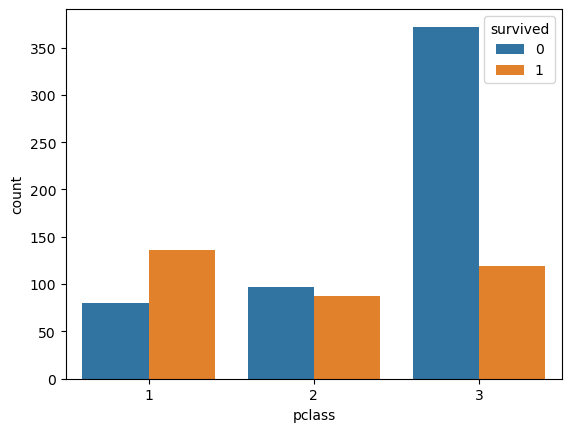

In [26]:

sns.countplot(data=df,x='pclass',hue='survived',order=[1,2,3])

<Axes: xlabel='sex'>

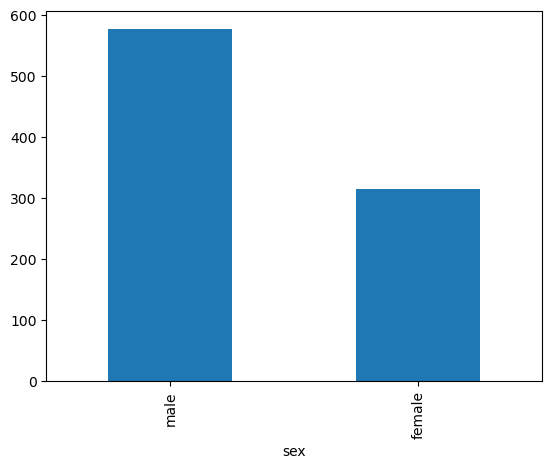

In [27]:
x['sex'].value_counts().plot(kind='bar')

In [28]:
print(df[(df['sex']=='male')&(df['survived']==0)].shape[0])
print(df[(df['sex']=='female')&(df['survived']==0)].shape[0])

468
81


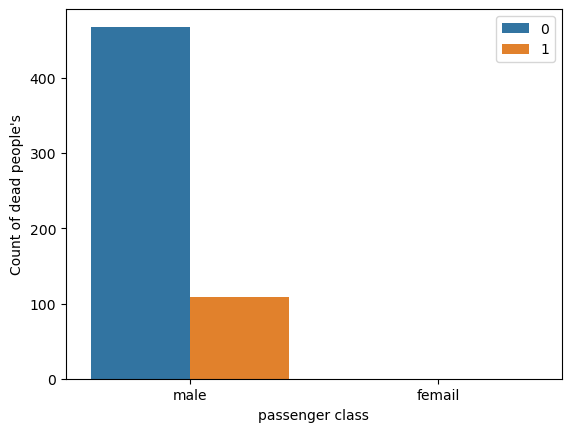

In [29]:
sns.countplot(data=df,x='sex',hue='survived',order=['male','femail'])
plt.xlabel("passenger class")
plt.ylabel("Count of dead people's")
plt.legend(loc='upper right')
plt.show()

In [30]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    object 
 2   age     891 non-null    float64
 3   fare    891 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 28.0+ KB


In [31]:
x['sex']=(x['sex']=='male').astype(int)

In [32]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pclass  891 non-null    int64  
 1   sex     891 non-null    int64  
 2   age     891 non-null    float64
 3   fare    891 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [33]:
x_dummies=df[['pclass','sex','age','fare']]
x_dummies.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [34]:
from sklearn.preprocessing import LabelEncoder

In [35]:
le=LabelEncoder()

In [36]:
x_dummies.head()

,pclass,sex,age,fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
sc = StandardScaler()

In [41]:
x_train_scaled = sc.fit_transform(x_train)

x_test_scaled = sc.transform(x_test)

In [42]:
x_train_scaled

array([[-1.61413602,  0.7243102 ,  1.25364106, -0.07868358],
       [-0.40055118,  0.7243102 , -0.47728355, -0.37714494],
       [ 0.81303367,  0.7243102 ,  0.21508629, -0.47486697],
       ...,
       [ 0.81303367,  0.7243102 ,  0.90745614, -0.35580399],
       [-1.61413602, -1.38062393, -1.1696534 ,  1.68320121],
       [-1.61413602,  0.7243102 , -0.63114352,  0.86074761]])

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
log_reg = LogisticRegression()

In [45]:
log_reg.fit(x_train_scaled,y_train)

LogisticRegression()

In [46]:
y_pred=log_reg.predict(x_test_scaled)

In [47]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[89, 16],
       [21, 53]])

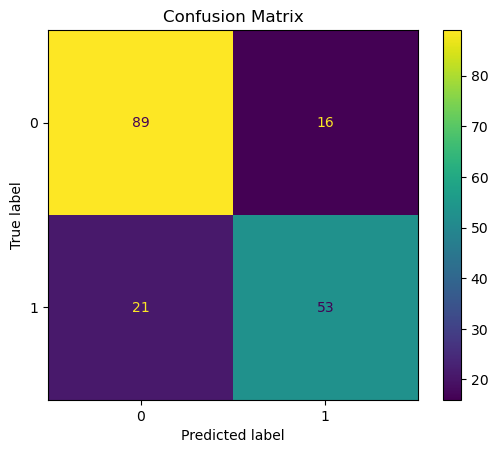

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.title("Confusion Matrix")
plt.show()

## A confusiion matrix is a table used to evaluate a classification model by comparing the actual class and predicted class.it shows both correct prediction and type of errors

In [49]:
print(accuracy_score(y_test,y_pred)*100)

79.3296089385475


In [50]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## Probability Prediction

In [51]:
y_pred=log_reg.predict(x_test_scaled)

In [52]:
y_prob=log_reg.predict_proba(x_test_scaled)
y_prob=log_reg.predict_proba(x_test_scaled)[:,1]

In [53]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

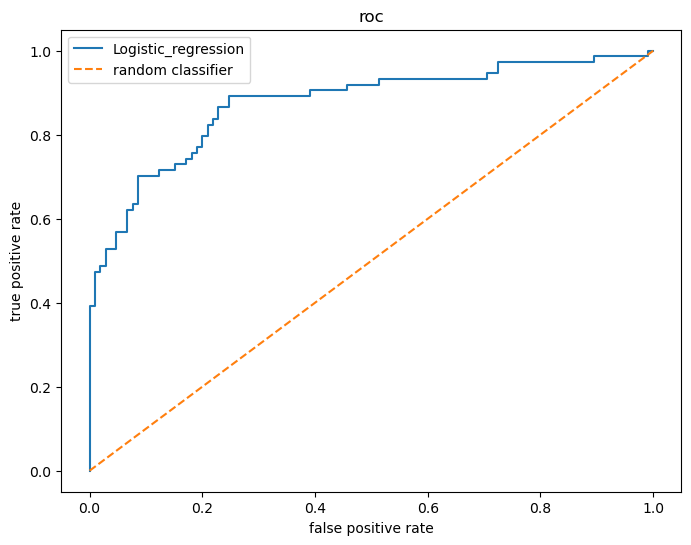

In [54]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label="Logistic_regression")
plt.plot([0,1],[0,1],linestyle='--',label="random classifier")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc")
plt.legend()
plt.show()

auc score 0.8745173745173744


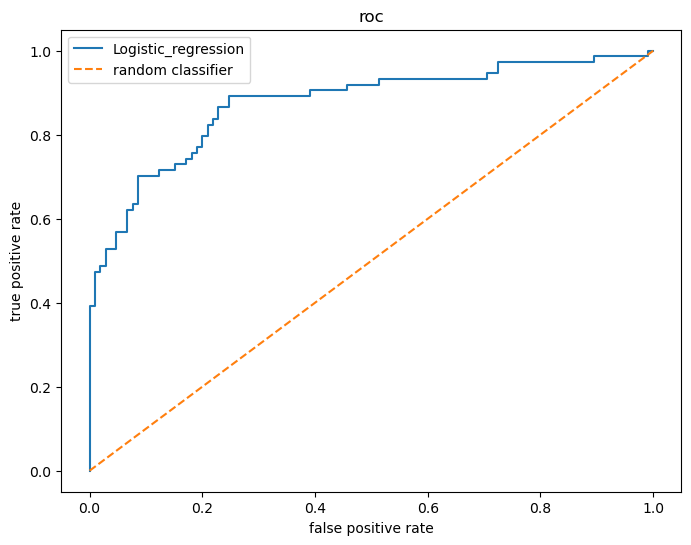

In [55]:
auc_score=roc_auc_score(y_test,y_prob)
print("auc score",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label="Logistic_regression")
plt.plot([0,1],[0,1],linestyle='--',label="random classifier")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("roc")
plt.legend()
plt.show()